# Random Forest Regression – Grid Search Optimization

**Goal:** Find the best Random Forest hyperparameters for both internal test
and stress-test performance.

**Workflow:**
1. Load data, define features, train/test split
2. Load and preprocess stress-test data
3. Run GridSearchCV across key parameters
4. Evaluate best model on both datasets
5. Run a stress-test focused grid
6. Compare all results: Decision Tree vs RF baseline vs RF tuned


## Step 1 – Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

print("All imports successful.")


All imports successful.


## Step 2 – Load Data and Train/Test Split

In [2]:
df = pd.read_csv("meat_price_dataset.csv")

target_col = "price_eur_per_kg"
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print(f"Features: {feature_cols}")


Train: 960 rows | Test: 240 rows
Features: ['meat_type', 'fat_content_pct', 'protein_pct', 'marbling_score', 'animal_age_months', 'storage_days', 'organic', 'cut_quality']


## Step 3 – Load and Preprocess Stress-Test Data

In [3]:
df_stress = pd.read_csv("meat_price_100_stress_test.csv")

X_stress = df_stress[feature_cols].copy()
y_stress = df_stress[target_col].copy()

# Impute with training medians
train_medians = X_train.median()
X_stress_filled = X_stress.fillna(train_medians)

# Drop rows where target is NaN
valid_mask = y_stress.notna()
X_stress_valid = X_stress_filled[valid_mask]
y_stress_valid = y_stress[valid_mask]

print(f"Stress-test rows: {X_stress_valid.shape[0]} / {len(df_stress)}")


Stress-test rows: 91 / 100


## Step 4 – GridSearchCV

**Parameters we search:**

| Parameter | What it controls |
|---|---|
| `n_estimators` | Number of trees in the forest |
| `max_depth` | Maximum depth per tree |
| `min_samples_leaf` | Minimum samples in each leaf — forces generalization |
| `max_features` | Features per split — controls tree diversity |

**Why `max_features` matters here:**
Our baseline forest had `meat_type` at 69% importance — all 200 trees
relied on the same feature. Setting `max_features="sqrt"` forces each
tree to consider only ~3 features per split, so some trees must learn
from weaker features. This creates **diversity** — the key ingredient
that makes a forest stronger than a single tree.


In [4]:
param_grid = {
    "n_estimators":    [100, 200, 300],
    "max_depth":       [3, 5, 7, 9, 11, None],
    "min_samples_leaf": [1, 3, 5, 10, 15],
    "max_features":    [None, "sqrt", "log2", 0.5],
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)

print(f"Total combinations: {len(grid.cv_results_['mean_test_score'])}")
print(f"Best MAE (CV): {-grid.best_score_:.2f} EUR")
print(f"Best params:   {grid.best_params_}")


Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Total combinations: 360
Best MAE (CV): 1.49 EUR
Best params:   {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 300}


## Step 5 – Evaluate Best Model on Both Datasets

In [5]:
best_rf = grid.best_estimator_

# --- Internal Test ---
y_pred = best_rf.predict(X_test)
mae_test  = mean_absolute_error(y_test, y_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test   = r2_score(y_test, y_pred)

# --- Stress Test ---
y_stress_pred = best_rf.predict(X_stress_valid)
mae_stress  = mean_absolute_error(y_stress_valid, y_stress_pred)
rmse_stress = np.sqrt(mean_squared_error(y_stress_valid, y_stress_pred))
r2_stress   = r2_score(y_stress_valid, y_stress_pred)

print("=== Internal Test ===")
print(f"MAE:  {mae_test:.2f} EUR")
print(f"RMSE: {rmse_test:.2f} EUR")
print(f"R²:   {r2_test:.4f}")
print(f"Relative error: {mae_test / y_test.mean() * 100:.1f}%")

print(f"=== Stress Test ===")
print(f"MAE:  {mae_stress:.2f} EUR")
print(f"RMSE: {rmse_stress:.2f} EUR")
print(f"R²:   {r2_stress:.4f}")
print(f"Relative error: {mae_stress / y_stress_valid.mean() * 100:.1f}%")


=== Internal Test ===
MAE:  1.65 EUR
RMSE: 2.03 EUR
R²:   0.9386
Relative error: 7.1%
=== Stress Test ===
MAE:  8.69 EUR
RMSE: 11.30 EUR
R²:   -0.3236
Relative error: 29.0%


## Step 6 – Feature Importance of Best Model

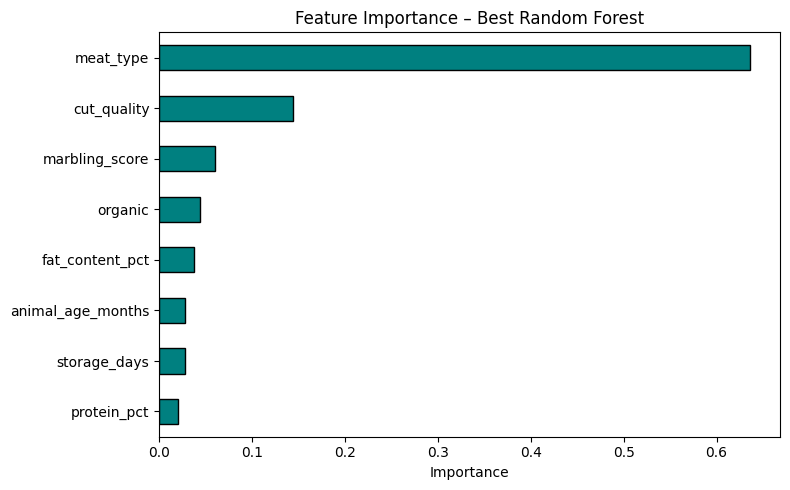

Importance values:
protein_pct          0.0208
storage_days         0.0281
animal_age_months    0.0284
fat_content_pct      0.0378
organic              0.0440
marbling_score       0.0600
cut_quality          0.1445
meat_type            0.6364
dtype: float64


In [6]:
importances = pd.Series(best_rf.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind="barh", ax=ax, color="teal", edgecolor="black")
ax.set_title("Feature Importance – Best Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Importance values:")
print(importances.round(4))


## Step 7 – Actual vs Predicted Plots (Best Model)


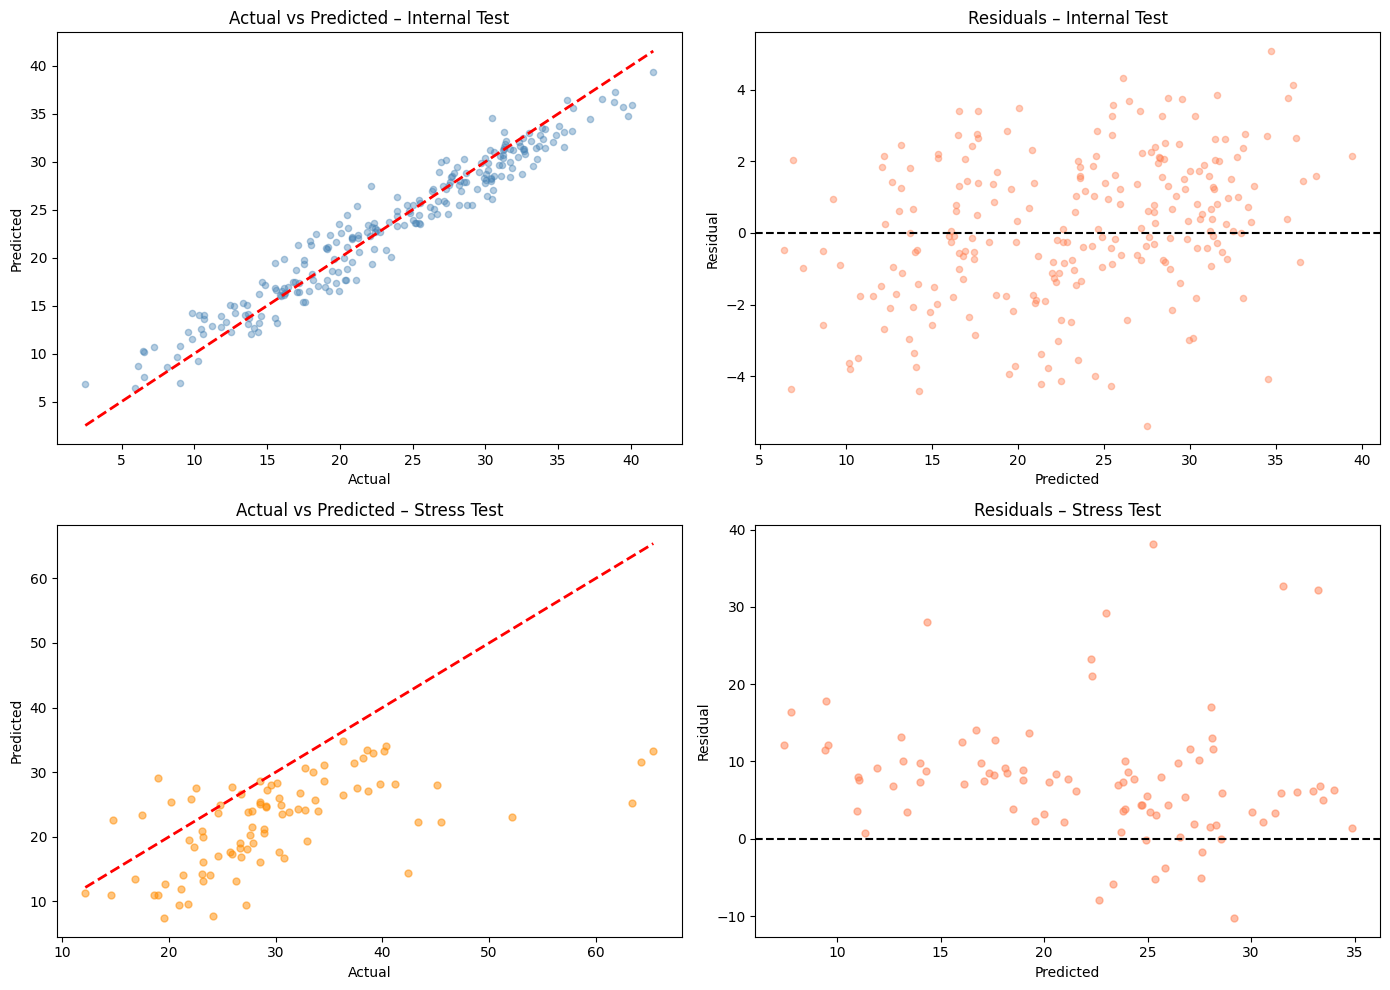

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Internal Test
axes[0, 0].scatter(y_test, y_pred, alpha=0.4, s=20, color="steelblue")
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                color="red", linestyle="--", linewidth=2)
axes[0, 0].set_xlabel("Actual")
axes[0, 0].set_ylabel("Predicted")
axes[0, 0].set_title("Actual vs Predicted – Internal Test")

residuals = y_test - y_pred
axes[0, 1].scatter(y_pred, residuals, alpha=0.4, s=20, color="coral")
axes[0, 1].axhline(y=0, color="black", linestyle="--")
axes[0, 1].set_xlabel("Predicted")
axes[0, 1].set_ylabel("Residual")
axes[0, 1].set_title("Residuals – Internal Test")

# Stress Test
axes[1, 0].scatter(y_stress_valid, y_stress_pred, alpha=0.5, s=25, color="darkorange")
axes[1, 0].plot([y_stress_valid.min(), y_stress_valid.max()],
                [y_stress_valid.min(), y_stress_valid.max()],
                color="red", linestyle="--", linewidth=2)
axes[1, 0].set_xlabel("Actual")
axes[1, 0].set_ylabel("Predicted")
axes[1, 0].set_title("Actual vs Predicted – Stress Test")

residuals_s = y_stress_valid - y_stress_pred
axes[1, 1].scatter(y_stress_pred, residuals_s, alpha=0.5, s=25, color="coral")
axes[1, 1].axhline(y=0, color="black", linestyle="--")
axes[1, 1].set_xlabel("Predicted")
axes[1, 1].set_ylabel("Residual")
axes[1, 1].set_title("Residuals – Stress Test")

plt.tight_layout()
plt.show()


## Step 8 – Stress-Test Focused Grid

Same idea as with the Decision Tree: search for simpler, more
conservative configurations that might generalize better.


In [8]:
results = []

for n_est in [100, 200, 300]:
    for depth in [2, 3, 4, 5, 7]:
        for min_leaf in [5, 10, 15, 20, 30]:
            for max_feat in [None, "sqrt", "log2", 0.3, 0.5]:

                rf = RandomForestRegressor(
                    n_estimators=n_est,
                    max_depth=depth,
                    min_samples_leaf=min_leaf,
                    max_features=max_feat,
                    random_state=42,
                    n_jobs=-1,
                )
                rf.fit(X_train, y_train)

                r2_t = r2_score(y_test, rf.predict(X_test))
                r2_s = r2_score(y_stress_valid, rf.predict(X_stress_valid))
                mae_t = mean_absolute_error(y_test, rf.predict(X_test))
                mae_s = mean_absolute_error(y_stress_valid, rf.predict(X_stress_valid))

                results.append({
                    "n_est":     n_est,
                    "depth":     depth,
                    "min_leaf":  min_leaf,
                    "max_feat":  str(max_feat),
                    "R2_test":   round(r2_t, 4),
                    "R2_stress": round(r2_s, 4),
                    "MAE_test":  round(mae_t, 2),
                    "MAE_stress": round(mae_s, 2),
                })

res_df = pd.DataFrame(results)

print(f"Total combinations tested: {len(res_df)}")
print("=== TOP 10 by Stress-Test R² ===")
print(res_df.sort_values("R2_stress", ascending=False).head(10).to_string(index=False))

print("=== TOP 10 balanced (R2_test + R2_stress) ===")
res_df["combined"] = res_df["R2_test"] + res_df["R2_stress"]
print(res_df.sort_values("combined", ascending=False).head(10).to_string(index=False))


Total combinations tested: 375
=== TOP 10 by Stress-Test R² ===
 n_est  depth  min_leaf max_feat  R2_test  R2_stress  MAE_test  MAE_stress
   100      7        10      0.3   0.8422    -0.2711      2.67        8.46
   100      7        10     sqrt   0.8422    -0.2711      2.67        8.46
   200      4        10     sqrt   0.7506    -0.2784      3.38        8.36
   200      4        10      0.3   0.7506    -0.2784      3.38        8.36
   200      4        30     sqrt   0.7223    -0.2787      3.56        8.32
   200      4        30      0.3   0.7223    -0.2787      3.56        8.32
   200      7        15      0.3   0.8131    -0.2790      2.90        8.45
   200      7        15     sqrt   0.8131    -0.2790      2.90        8.45
   200      4         5     sqrt   0.7516    -0.2791      3.36        8.36
   200      4         5      0.3   0.7516    -0.2791      3.36        8.36
=== TOP 10 balanced (R2_test + R2_stress) ===
 n_est  depth  min_leaf max_feat  R2_test  R2_stress  MAE_test  M

## Step 9 – Full Comparison: Decision Tree vs Random Forest


In [9]:
print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

comparison = pd.DataFrame({
    "Model": [
        "Decision Tree (depth 7)",
        "Decision Tree GridSearch",
        "Random Forest baseline",
        "Random Forest GridSearch",
    ],
    "MAE Test": ["2.38", "2.18", f"{mae_test:.2f}", "(from Step 8)"],
    "R² Test":  ["0.8737", "0.8875", f"{r2_test:.4f}", "(from Step 8)"],
    "MAE Stress": ["8.59", "8.70", f"{mae_stress:.2f}", "(from Step 8)"],
    "R² Stress":  ["-0.2544", "-0.3108", f"{r2_stress:.4f}", "(from Step 8)"],
})

print(comparison.to_string(index=False))
print("Update the last row with the best results from Step 8.")
print("--- Done! ---")


MODEL COMPARISON
                   Model      MAE Test       R² Test    MAE Stress     R² Stress
 Decision Tree (depth 7)          2.38        0.8737          8.59       -0.2544
Decision Tree GridSearch          2.18        0.8875          8.70       -0.3108
  Random Forest baseline          1.65        0.9386          8.69       -0.3236
Random Forest GridSearch (from Step 8) (from Step 8) (from Step 8) (from Step 8)
Update the last row with the best results from Step 8.
--- Done! ---
